
# Tier 1 — National Screening: CCS Potential Across Indonesian Basins

**Status: PROTOTYPE.** This notebook uses **real basin metadata**, **real basin boundaries (area)**,
and **real industrial emissions data** if present, falling back to illustrative sample data otherwise.

## Screening Strategy
This notebook follows the Tier 1 definition in `docs/methodology.md` (§2): an
**SRL 1 basin-level inventory** built from public metadata, reported with a
**comparison table + proximity map** — not a site-specific capacity study.

1. **Full inventory (Section 1):** every basin in the dataset is kept and labelled
   with a Storage Readiness Level (SRL 1 = "Unexplored", SRL 2 = "Producing"/"Discovery"/"Prospect"),
   per the Nooraiepour et al. (2025) SRL scale referenced in `docs/methodology.md` §1.2.
2. **Quantitative subset (Section 2a):** Monte Carlo storage volume and proximity-to-emitter scoring
   are run **only** on SRL 2 basins (Producing/Discovery/Prospect).
3. **Geological & Geographic Screening (Section 2b - 2c):** Basins are evaluated based on their tectonic 
   classification (`TEC_EXP`) and are passed through a **GEBCO bathymetry filter** to eliminate 
   Onshore basins (elevation $\ge 0$m).
4. **Curated Ranking (Section 4b):** A strict Hard Filter removes Fore-Arc basins and unconfirmed prospects. 
   The remaining elite basins are normalized and ranked using a **Cost-Effective Score (60% Proximity, 40% Volume)** 
   to find the Top 3 candidates.
5. **This notebook's ranking is a data-driven recommendation.** The ultimate Tier 2 selection is finalized 
   using qualitative criteria (policy priority, structural analogy).


## 0. Setup

In [1]:

import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

_p = Path.cwd()
while not (_p / "config.yaml").exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT / "src"))

from load_config import load_config
from emission_source_proximity import nearest_emitter_distance, basin_accessibility_scores
from montecarlo_capacity import monte_carlo_capacity, summarize_capacity, NormalParam

cfg = load_config(REPO_ROOT / "config.yaml")
pd.set_option("display.max_colwidth", 60)
print("Repo root:", REPO_ROOT)
print("Target SRL Tier 1:", cfg["storage_readiness"]["tier1_target_srl"])


Repo root: c:\Users\Arsy Nuur\ccs-screening
Target SRL Tier 1: 1


## 1. Load basin & emission source data (full SRL 1 inventory, no basins dropped)

In [2]:

real_basins_path = REPO_ROOT / cfg["paths"]["real"]["basins_processed"]
real_emitters_path = REPO_ROOT / cfg["paths"]["real"]["emitters"]
sample_basins_path = REPO_ROOT / cfg["paths"]["sample"]["basins"]
sample_emitters_path = REPO_ROOT / cfg["paths"]["sample"]["emitters"]

# Generate sample files if missing
if not sample_basins_path.exists() or not sample_emitters_path.exists():
    subprocess.run([sys.executable, str(REPO_ROOT / "src" / "fetch_open_data.py"), "--mode", "sample"], check=True)

print("=== ACTIVE DATA SOURCE ===")
if real_basins_path.exists():
    basins_path, basins_source = real_basins_path, "REAL"
else:
    basins_path, basins_source = sample_basins_path, "ILLUSTRATIVE (sample)"
print(f"Basins  : {basins_source} -> {basins_path.name}")

if real_emitters_path.exists():
    emitters_path, emitters_source = real_emitters_path, "REAL"
else:
    emitters_path, emitters_source = sample_emitters_path, "ILLUSTRATIVE (sample)"
print(f"Emitters: {emitters_source} -> {emitters_path.name}")
print("==========================\n")

basins = pd.read_csv(basins_path)
emitters = pd.read_csv(emitters_path)

# --- DYNAMIC BASIN COLUMN ALIGNMENT ---
basin_rename = {}
for col in basins.columns:
    col_lower = col.lower()
    if col_lower in ["basin", "basin_name", "basin_nam", "name", "nama"]:
        basin_rename[col] = "basin"
    elif col_lower in ["lat", "latitude", "y", "centroid_y", "lat_centroid"]:
        basin_rename[col] = "lat"
    elif col_lower in ["lon", "longitude", "lng", "x", "lon_centroid"]:
        basin_rename[col] = "lon"
    elif col_lower in ["regional", "region", "province"]:
        basin_rename[col] = "region"
    elif col_lower in ["tec_exp", "basin_type", "type", "classification"]:
        basin_rename[col] = "basin_type"
    elif col_lower in ["stat2022", "status", "exploration_status"]:
        basin_rename[col] = "status"

basins = basins.rename(columns=basin_rename)

# Ensure essential columns exist
if "basin" not in basins.columns:
    basins["basin"] = [f"Basin_{i+1}" for i in range(len(basins))]
if "region" not in basins.columns:
    basins["region"] = "unknown"
if "basin_type" not in basins.columns:
    basins["basin_type"] = "sedimentary"
if "status" not in basins.columns:
    basins["status"] = "Unexplored basin with no and/or limited data available"
if "ccs_policy_priority" not in basins.columns:
    basins["ccs_policy_priority"] = "Standard"

# For the illustrative sample data run, mock some statuses and tectonic types
if basins_source == "ILLUSTRATIVE (sample)":
    np.random.seed(42)
    demo_statuses = ["Producing basin", "Discovery basin", "Prospect basin", "Unexplored basin"]
    demo_tectonics = ["Back-Arc", "Passive Margin", "Rifted Graben", "Fore-Arc", "Intermontane Basin"]
    basins["status"] = np.random.choice(demo_statuses, size=len(basins))
    basins["basin_type"] = np.random.choice(demo_tectonics, size=len(basins))

# --- SRL LABELLING (no basin is dropped here) ---
# Aligned to real data: "Producing", "Discovery", and "Prospect" imply well data / confirmed hydrocarbons.
def map_status_to_srl(status):
    s = str(status).lower()
    if any(k in s for k in ["producing", "discovery", "prospect"]):
        return 2  # SRL 2: data systematically mapped from well data or proven hydrocarbon systems
    else:
        return 1  # SRL 1: basin-scale, unexplored / public G&G data only

basins["srl_placeholder"] = basins["status"].apply(map_status_to_srl)

srl_counts = basins["srl_placeholder"].value_counts().sort_index()
print("=== FULL SRL 1 INVENTORY (all basins retained) ===")
print(f"SRL 1 (Unexplored)                  : {srl_counts.get(1, 0)} basins")
print(f"SRL 2 (Producing/Discovery/Prospect): {srl_counts.get(2, 0)} basins")
print(f"Total basins in inventory           : {len(basins)}\n")
print("Note: SRL 1 basins are shown below for completeness (per methodology §2's")
print("SRL-1 inventory target) but are excluded from Sections 3-5's quantitative")
print("Monte Carlo capacity and proximity scoring.\n")

# Align emitter column names
emitters = emitters.rename(columns={
    "Latitude": "lat", "Longitude": "lon", "annual_co2_mtpa": "capacity_mtpa_co2_est",
})
if "name" not in emitters.columns:
    emitters["name"] = emitters.get("Plant name", "unnamed_emitter")
if "sector" not in emitters.columns:
    emitters["sector"] = "unknown"

print(f"{len(emitters)} emitter points loaded.")


=== ACTIVE DATA SOURCE ===
Basins  : REAL -> basins_processed.csv
Emitters: REAL -> indonesia_emitters_real.csv

=== FULL SRL 1 INVENTORY (all basins retained) ===
SRL 1 (Unexplored)                  : 69 basins
SRL 2 (Producing/Discovery/Prospect): 59 basins
Total basins in inventory           : 128

Note: SRL 1 basins are shown below for completeness (per methodology §2's
SRL-1 inventory target) but are excluded from Sections 3-5's quantitative
Monte Carlo capacity and proximity scoring.

526 emitter points loaded.


## 2a. Quantitative subset: SRL 2 basins carried into Sections 3-5

Everything from here on operates on `basins_qualified` (SRL 2 only). This is a **feasibility gate for quantitative modelling**, distinct
from the SRL 1 inventory built in Section 1.

In [3]:

basins_qualified = basins[basins["srl_placeholder"] >= 2].copy()
excluded = basins[basins["srl_placeholder"] < 2]["basin"].tolist()

print(f"Carried into quantitative scoring: {len(basins_qualified)} basin(s).")

srl_labels = {1: "SRL 1 - basin-scale, unexplored / public data", 2: "SRL 2 - systematically mapped (wells/prospect)"}
basins_qualified["srl_label"] = basins_qualified["srl_placeholder"].map(srl_labels)


Carried into quantitative scoring: 59 basin(s).


## 2b. Tectonic Classification (TEC_EXP) & Geological Screening

Following the framework of **de Jonge-Anderson et al. (2025)**, the tectonic setting of a basin heavily controls its porosity-depth trends and geothermal gradients. We apply a geological suitability scoring matrix to the active basins:

*   **Score 3 (High Priority): Back-Arc & Passive Margin.** Excellent reservoir quality, thick regional shale seals.
*   **Score 2 (Medium Priority): Intra-Arc / Rifted Graben / Foreland / Intermontane.** High geothermal gradients reduce $CO_2$ density, or mixed reservoir quality.
*   **Score 1 (Low Priority / Disqualified): Fore-Arc / Trench / Deep Oceanic.** High seismicity, caprock failure risks, poor lithic reservoirs at depth.


In [4]:

def map_tectonic_score(tec_exp):
    s = str(tec_exp).lower()
    
    # 1. Eliminators: High Risk Subduction / Oceanic 
    if any(k in s for k in ["fore arc", "fore-arc", "trench", "oceanic"]):
        return 1, "Fore-Arc / Deep Oceanic"
    
    # 2. High Priority: Stable Post-Rift / Margin
    elif any(k in s for k in ["back arc", "back-arc", "passive", "margin"]):
        return 3, "Back-Arc / Passive Margin"
    
    # 3. Medium Priority: Complex, active, or inland extensional setups
    elif any(k in s for k in ["rift", "graben", "intra-arc", "intra arc", "intermontane", "foreland", "transtensional"]):
        return 2, "Intra-Arc / Rift / Foreland"
        
    else:
        return 2, "Unclassified / Intermediate"

# Apply tectonic scoring logic
scores_and_classes = basins_qualified["basin_type"].apply(map_tectonic_score)
basins_qualified["tectonic_score"] = [x[0] for x in scores_and_classes]
basins_qualified["tectonic_class"] = [x[1] for x in scores_and_classes]

print("=== TECTONIC CLASSIFICATION DISTRIBUTION (SRL 2 Basins) ===")
print(basins_qualified["tectonic_class"].value_counts())


=== TECTONIC CLASSIFICATION DISTRIBUTION (SRL 2 Basins) ===
tectonic_class
Back-Arc / Passive Margin      35
Intra-Arc / Rift / Foreland    15
Fore-Arc / Deep Oceanic         9
Name: count, dtype: int64


## 2c. Offshore / Coastal Pre-screening (GEBCO Bathymetry)

To minimize land-use conflicts and prioritize high-capacity fluid sinks, this pipeline employs a geophysical shortcut using **GEBCO Bathymetry data**. 

We extract the digital elevation at the geographic centroid (lon, lat) of each SRL 2 basin:
*   **Elevation $< 0$ meter:** Basin is predominantly located Offshore or Coastal. **(Kept in pipeline)**
*   **Elevation $\ge 0$ meter:** Basin centroid is located Onshore. **(Filtered Out)**


In [5]:

# Try to resolve GEBCO path from config
try:
    gebco_path_str = cfg["paths"]["real"]["grid_gebco"]
except KeyError:
    gebco_path_str = "data/gebco_2023.tif"
    
gebco_path = REPO_ROOT / gebco_path_str
basins_qualified["elevation_m"] = np.nan

print("\n" + "="*40)
print("=== ACTIVE BATHYMETRY DATA SOURCE ===")
print("="*40)

# 1. Evaluate True Elevation Data (if available)
is_real_gebco = False
if gebco_path.exists():
    is_real_gebco = True
    if gebco_path.suffix == '.nc':
        print(f"DATA : REAL (NetCDF) -> {gebco_path.name}")
        try:
            import xarray as xr
            ds = xr.open_dataset(gebco_path)
            elevations = []
            for _, row in basins_qualified.iterrows():
                # Assuming standard NetCDF coordinate names
                val = ds.sel(lon=row["lon"], lat=row["lat"], method="nearest")['elevation'].values
                elevations.append(float(val))
            basins_qualified["elevation_m"] = elevations
        except Exception as e:
            print(f"⚠️ Error reading GEBCO NetCDF: {e}")
            is_real_gebco = False
            
    else: # Assume GeoTIFF (.tif)
        print(f"DATA : REAL (GeoTIFF) -> {gebco_path.name}")
        try:
            import rasterio
            with rasterio.open(gebco_path) as src:
                coords = [(row["lon"], row["lat"]) for _, row in basins_qualified.iterrows()]
                elevations = [val[0] for val in src.sample(coords)]
                basins_qualified["elevation_m"] = elevations
        except Exception as e:
            print(f"⚠️ Error reading GEBCO GeoTIFF: {e}")
            is_real_gebco = False

# 2. Mock Fallback Data (if file is missing, prevent pipeline crash during prototyping)
if not is_real_gebco or basins_qualified["elevation_m"].isna().all():
    print(f"DATA : ILLUSTRATIVE (Mocked random elevations)")
    print(f"⚠️ File not found at {gebco_path} or missing library.")
    np.random.seed(123)
    basins_qualified["elevation_m"] = np.random.uniform(-2000, 500, size=len(basins_qualified))

# 3. Apply the Filter
basins_offshore = basins_qualified[basins_qualified["elevation_m"] < 0].copy()
onshore_excluded = basins_qualified[basins_qualified["elevation_m"] >= 0]["basin"].tolist()

print(f"\nTotal SRL 2 Basins before screen : {len(basins_qualified)}")
print(f"Offshore/Coastal (Kept, < 0m)    : {len(basins_offshore)} basins")
print(f"Onshore (Dropped, >= 0m)         : {len(onshore_excluded)} basins")

# Enforce the drop: Update the qualified subset moving forward
basins_qualified = basins_offshore



=== ACTIVE BATHYMETRY DATA SOURCE ===
DATA : REAL (NetCDF) -> gebco_2026_n-4.0_s-6.0_w105.5_e108.0.nc

Total SRL 2 Basins before screen : 59
Offshore/Coastal (Kept, < 0m)    : 50 basins
Onshore (Dropped, >= 0m)         : 9 basins


## 3. Proximity to CO2 emission sources (SRL 2 Offshore Basins only)

In [6]:

capacity_col = "capacity_mtpa_co2_est" if "capacity_mtpa_co2_est" in emitters.columns else None

basins_with_proximity = nearest_emitter_distance(
    basins_qualified, emitters,
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    emitter_capacity_col=capacity_col,
)
cols = ["basin", "nearest_emitter_name", "nearest_emitter_km"]
if "nearest_emitter_capacity" in basins_with_proximity.columns:
    cols.append("nearest_emitter_capacity")
basins_with_proximity[cols].sort_values("nearest_emitter_km").head()


,basin,nearest_emitter_name,nearest_emitter_km,nearest_emitter_capacity
30,Serayu Utara,Central Java Power Project,17.078038,4.467210
52,Kutai,Kaltim-4 power station,21.425368,0.593612
28,Jawa Tengah Selatan,Kulon Progo power station,22.622343,0.000000
27,Banyumas,Cilacap Sumber power station,28.230988,1.780835
18,Jawa Barat,Indramayu power station,29.671326,1.958919


### 3b. Catchment / accessibility analysis (within 200 km)

In [7]:

ts = cfg["tier1_scoring"]

basins_scored = basin_accessibility_scores(
    basins_qualified, emitters,
    radius_km=ts["search_radius_km"],
    min_distance_floor_km=ts["min_distance_floor_km"],
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    capacity_col="capacity_mtpa_co2_est" if "capacity_mtpa_co2_est" in emitters.columns else "lat",
)
basins_scored[["basin", "n_emitters_within_radius", "total_capacity_within_radius_mtpa", "accessibility_index"]] \
    .sort_values("accessibility_index", ascending=False).head()


,basin,n_emitters_within_radius,total_capacity_within_radius_mtpa,accessibility_index
9,Serayu Utara,30,55.184993,0.915553
6,Banyumas,28,47.892778,0.759532
25,Tomori,44,49.991785,0.739365
3,Ujung Kulon,51,72.774824,0.629913
8,Jawa Tengah Utara,32,58.924747,0.608938


## 4. Resource-reserve pyramid per basin (Monte Carlo, SRL 2 Offshore Basins)

In [8]:

ce = cfg["capacity_equation"]
rng = np.random.default_rng(42)
illustrative_results = []

for _, row in basins_qualified.iterrows():
    # Detect and utilize real surface area if available, otherwise use fallback range
    if "area_sqkm" in row and not pd.isna(row["area_sqkm"]):
        area_km2 = float(row["area_sqkm"])
        area_type = "REAL"
    elif "area_km2" in row and not pd.isna(row["area_km2"]):
        area_km2 = float(row["area_km2"])
        area_type = "REAL"
    else:
        area_km2 = rng.uniform(5_000, 70_000)
        area_type = "RANDOM (illustrative)"

    mc = monte_carlo_capacity(
        area_km2=area_km2,
        thickness_m=NormalParam(mean=rng.uniform(150, 500), std=100, lower_bound=0),
        ntg_fraction=NormalParam(mean=rng.uniform(0.15, 0.4), std=0.1, lower_bound=0, upper_bound=1),
        porosity_fraction=NormalParam(mean=rng.uniform(0.15, 0.28), std=0.04, lower_bound=0, upper_bound=1),
        swirr_fraction=NormalParam(mean=ce["swirr_mean"], std=ce["swirr_std"], lower_bound=0, upper_bound=1),
        efficiency_fraction=NormalParam(
            mean=ce["efficiency_factor_percent_mean"] / 100,
            std=ce["efficiency_factor_percent_std"] / 100,
            lower_bound=0, upper_bound=1,
        ),
        co2_density_kgm3=NormalParam(mean=rng.uniform(300, 450), std=40, lower_bound=0),
        n_iterations=ce["monte_carlo_iterations"],
        random_seed=int(rng.integers(0, 10_000)),
    )
    stats = summarize_capacity(mc)
    stats["basin"] = row["basin"]
    stats["area_km2"] = area_km2
    stats["area_source"] = area_type
    illustrative_results.append(stats)

illustrative_df = pd.DataFrame(illustrative_results).set_index("basin")
illustrative_df = illustrative_df[["area_km2", "area_source", "P10_Gt", "P50_Gt", "P90_Gt", "mean_Gt", "std_Gt"]]


### 4b. Ranking SRL 2 candidates (Cost-Effective Hard Filter)
*Formatted for Journal / Report extraction.*

In [9]:

ranking_df = illustrative_df.merge(
    basins_scored.set_index("basin")[["lat", "lon", "accessibility_index", "total_capacity_within_radius_mtpa", "n_emitters_within_radius"]],
    left_index=True, right_index=True,
)
ranking_df = ranking_df.merge(
    basins_qualified.set_index("basin")[["status", "tectonic_class", "tectonic_score"]],
    left_index=True, right_index=True,
)

def safe_minmax(series):
    diff = series.max() - series.min()
    if diff == 0 or pd.isna(diff):
        return pd.Series(1.0, index=series.index)
    return (series - series.min()) / diff

# Global normalization for plotting purposes (includes ALL offshore SRL 2 basins)
ranking_df["norm_volume_global"] = safe_minmax(ranking_df["P50_Gt"])
ranking_df["norm_proximity_global"] = safe_minmax(ranking_df["total_capacity_within_radius_mtpa"])

# Sorts for Stage 1 and Stage 2 top 10 prints
storage_sorted = ranking_df.sort_values(by="P50_Gt", ascending=False)
emitter_sorted = ranking_df.sort_values(by="total_capacity_within_radius_mtpa", ascending=False)

# --- 1. HARD FILTER (Geological Qualification & Data Maturity) ---
# Filter out Fore-Arc, Rift, etc., keeping only Back-Arc/Passive Margin.
# Restrict to Producing or Discovery (removing unconfirmed 'Prospect' basins).
df_scoring = ranking_df[
    (ranking_df["tectonic_class"].str.contains("Back-Arc|Passive", case=False, na=False)) &
    (ranking_df["status"].str.contains("Producing|Discovery", case=False, na=False))
].copy()

# --- 2. LOCAL NORMALIZATION & COST-EFFECTIVE SCORING ---
robust_picks = []
if not df_scoring.empty:
    # Scale 0-1 based ONLY on the elite filtered candidates
    df_scoring["norm_volume"] = safe_minmax(df_scoring["P50_Gt"])
    df_scoring["norm_proximity"] = safe_minmax(df_scoring["total_capacity_within_radius_mtpa"])
    
    # Calculate Cost-Effective Score (Proximity 60%, Volume 40%)
    df_scoring["cost_effective_score"] = (df_scoring["norm_proximity"] * 0.6) + (df_scoring["norm_volume"] * 0.4)
    
    # Identify Top 3 Basins
    top_3_basins = df_scoring.sort_values(by="cost_effective_score", ascending=False).head(3)
    robust_picks = top_3_basins.index.tolist()
    
    # Merge the final score back into the global dataframe for map tooltips
    ranking_df = ranking_df.join(df_scoring[["cost_effective_score"]])
else:
    top_3_basins = pd.DataFrame()
    ranking_df["cost_effective_score"] = np.nan

# --- HTML STYLER FUNCTION FOR PUBLICATION-READY TABLES ---
def style_dataframe(df, highlight_col, format_dict, cmap="BuGn"):
    return df.style \
        .format(format_dict) \
        .background_gradient(cmap=cmap, subset=[highlight_col]) \
        .set_properties(**{
            'text-align': 'left', 
            'font-family': 'DejaVu Sans, Arial, sans-serif', 
            'padding': '8px', 
            'border-bottom': '1px solid #ddd'
        }) \
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#1A365D'), 
                ('color', 'white'), 
                ('font-weight', 'bold'),
                ('text-align', 'left')
            ]}
        ])

display(HTML("<h3 style='color:#1A365D;'>=== RANKING STAGE 1: PHYSICAL STORAGE VOLUME (Top 10) ===</h3>"))
df_stg1 = storage_sorted[["status", "tectonic_class", "area_km2", "P50_Gt", "area_source"]].head(10)
display(style_dataframe(df_stg1, "P50_Gt", {"P50_Gt": "{:.2f} Gt", "area_km2": "{:,.0f} km²"}))

display(HTML("<h3 style='color:#1A365D; margin-top:20px;'>=== RANKING STAGE 2: TOTAL AVAILABLE CO2 VOLUME (Top 10) ===</h3>"))
df_stg2 = emitter_sorted[["status", "tectonic_class", "total_capacity_within_radius_mtpa", "n_emitters_within_radius"]].head(10)
display(style_dataframe(df_stg2, "total_capacity_within_radius_mtpa", {"total_capacity_within_radius_mtpa": "{:.2f} Mtpa"}, cmap="OrRd"))

display(HTML("<h3 style='color:#2F855A; margin-top:20px;'>=== RECOMMENDED TOP 3 BASINS FOR TIER 2 (COST-EFFECTIVE) ===</h3>"))
if not top_3_basins.empty:
    cols_to_show = ["status", "tectonic_class", "P50_Gt", "total_capacity_within_radius_mtpa", "cost_effective_score"]
    display(style_dataframe(top_3_basins[cols_to_show], "cost_effective_score", {
        "P50_Gt": "{:.2f} Gt", 
        "total_capacity_within_radius_mtpa": "{:.2f} Mtpa", 
        "cost_effective_score": "{:.3f}"
    }, cmap="YlGnBu"))
else:
    print("No basins passed the strict Geologic and Data Maturity Hard Filters.")


,status,tectonic_class,area_km2,P50_Gt,area_source
basin,,,,,
Natuna Barat,Producing basin,Back-Arc / Passive Margin,"105,456 km²",16.23 Gt,REAL
Jawa Timur Utara,Producing basin,Back-Arc / Passive Margin,"118,249 km²",12.47 Gt,REAL
Natuna Timur,Discovery basin,Back-Arc / Passive Margin,"85,063 km²",11.40 Gt,REAL
Laut Timor,Discovery basin,Back-Arc / Passive Margin,"73,865 km²",9.28 Gt,REAL
Akimeugah,Discovery basin,Back-Arc / Passive Margin,"88,582 km²",8.73 Gt,REAL
Arafura,Prospect basin with proven petroleum system,Back-Arc / Passive Margin,"67,081 km²",8.07 Gt,REAL
Kutai,Producing basin,Back-Arc / Passive Margin,"130,970 km²",8.01 Gt,REAL
Aru - Tanimbar,Discovery basin,Fore-Arc / Deep Oceanic,"102,336 km²",7.91 Gt,REAL
Seram,Producing basin,Fore-Arc / Deep Oceanic,"59,288 km²",6.98 Gt,REAL


,status,tectonic_class,total_capacity_within_radius_mtpa,n_emitters_within_radius
basin,,,,
Ujung Kulon,Discovery basin,Intra-Arc / Rift / Foreland,72.77 Mtpa,51
Sunda Asri,Producing basin,Back-Arc / Passive Margin,66.19 Mtpa,51
Banggai,Producing basin,Back-Arc / Passive Margin,60.42 Mtpa,57
Jawa Tengah Utara,Discovery basin,Back-Arc / Passive Margin,58.92 Mtpa,32
Jawa Tengah Selatan,Prospect basin with hydrocarbon indication,Intra-Arc / Rift / Foreland,58.92 Mtpa,32
Serayu Utara,Producing basin,Back-Arc / Passive Margin,55.18 Mtpa,30
Tomori,Prospect basin with hydrocarbon indication,Intra-Arc / Rift / Foreland,49.99 Mtpa,44
Manui,Prospect basin with proven petroleum system,Back-Arc / Passive Margin,48.05 Mtpa,57
Banyumas,Discovery basin,Intra-Arc / Rift / Foreland,47.89 Mtpa,28


,status,tectonic_class,P50_Gt,total_capacity_within_radius_mtpa,cost_effective_score
basin,,,,,
Sunda Asri,Producing basin,Back-Arc / Passive Margin,3.50 Gt,66.19 Mtpa,0.678
Banggai,Producing basin,Back-Arc / Passive Margin,5.28 Gt,60.42 Mtpa,0.671
Jawa Timur Utara,Producing basin,Back-Arc / Passive Margin,12.47 Gt,31.10 Mtpa,0.587


## 5. Summary Visualization (Publication-Grade)

findfont: Failed to find font weight semibold, now using 700.


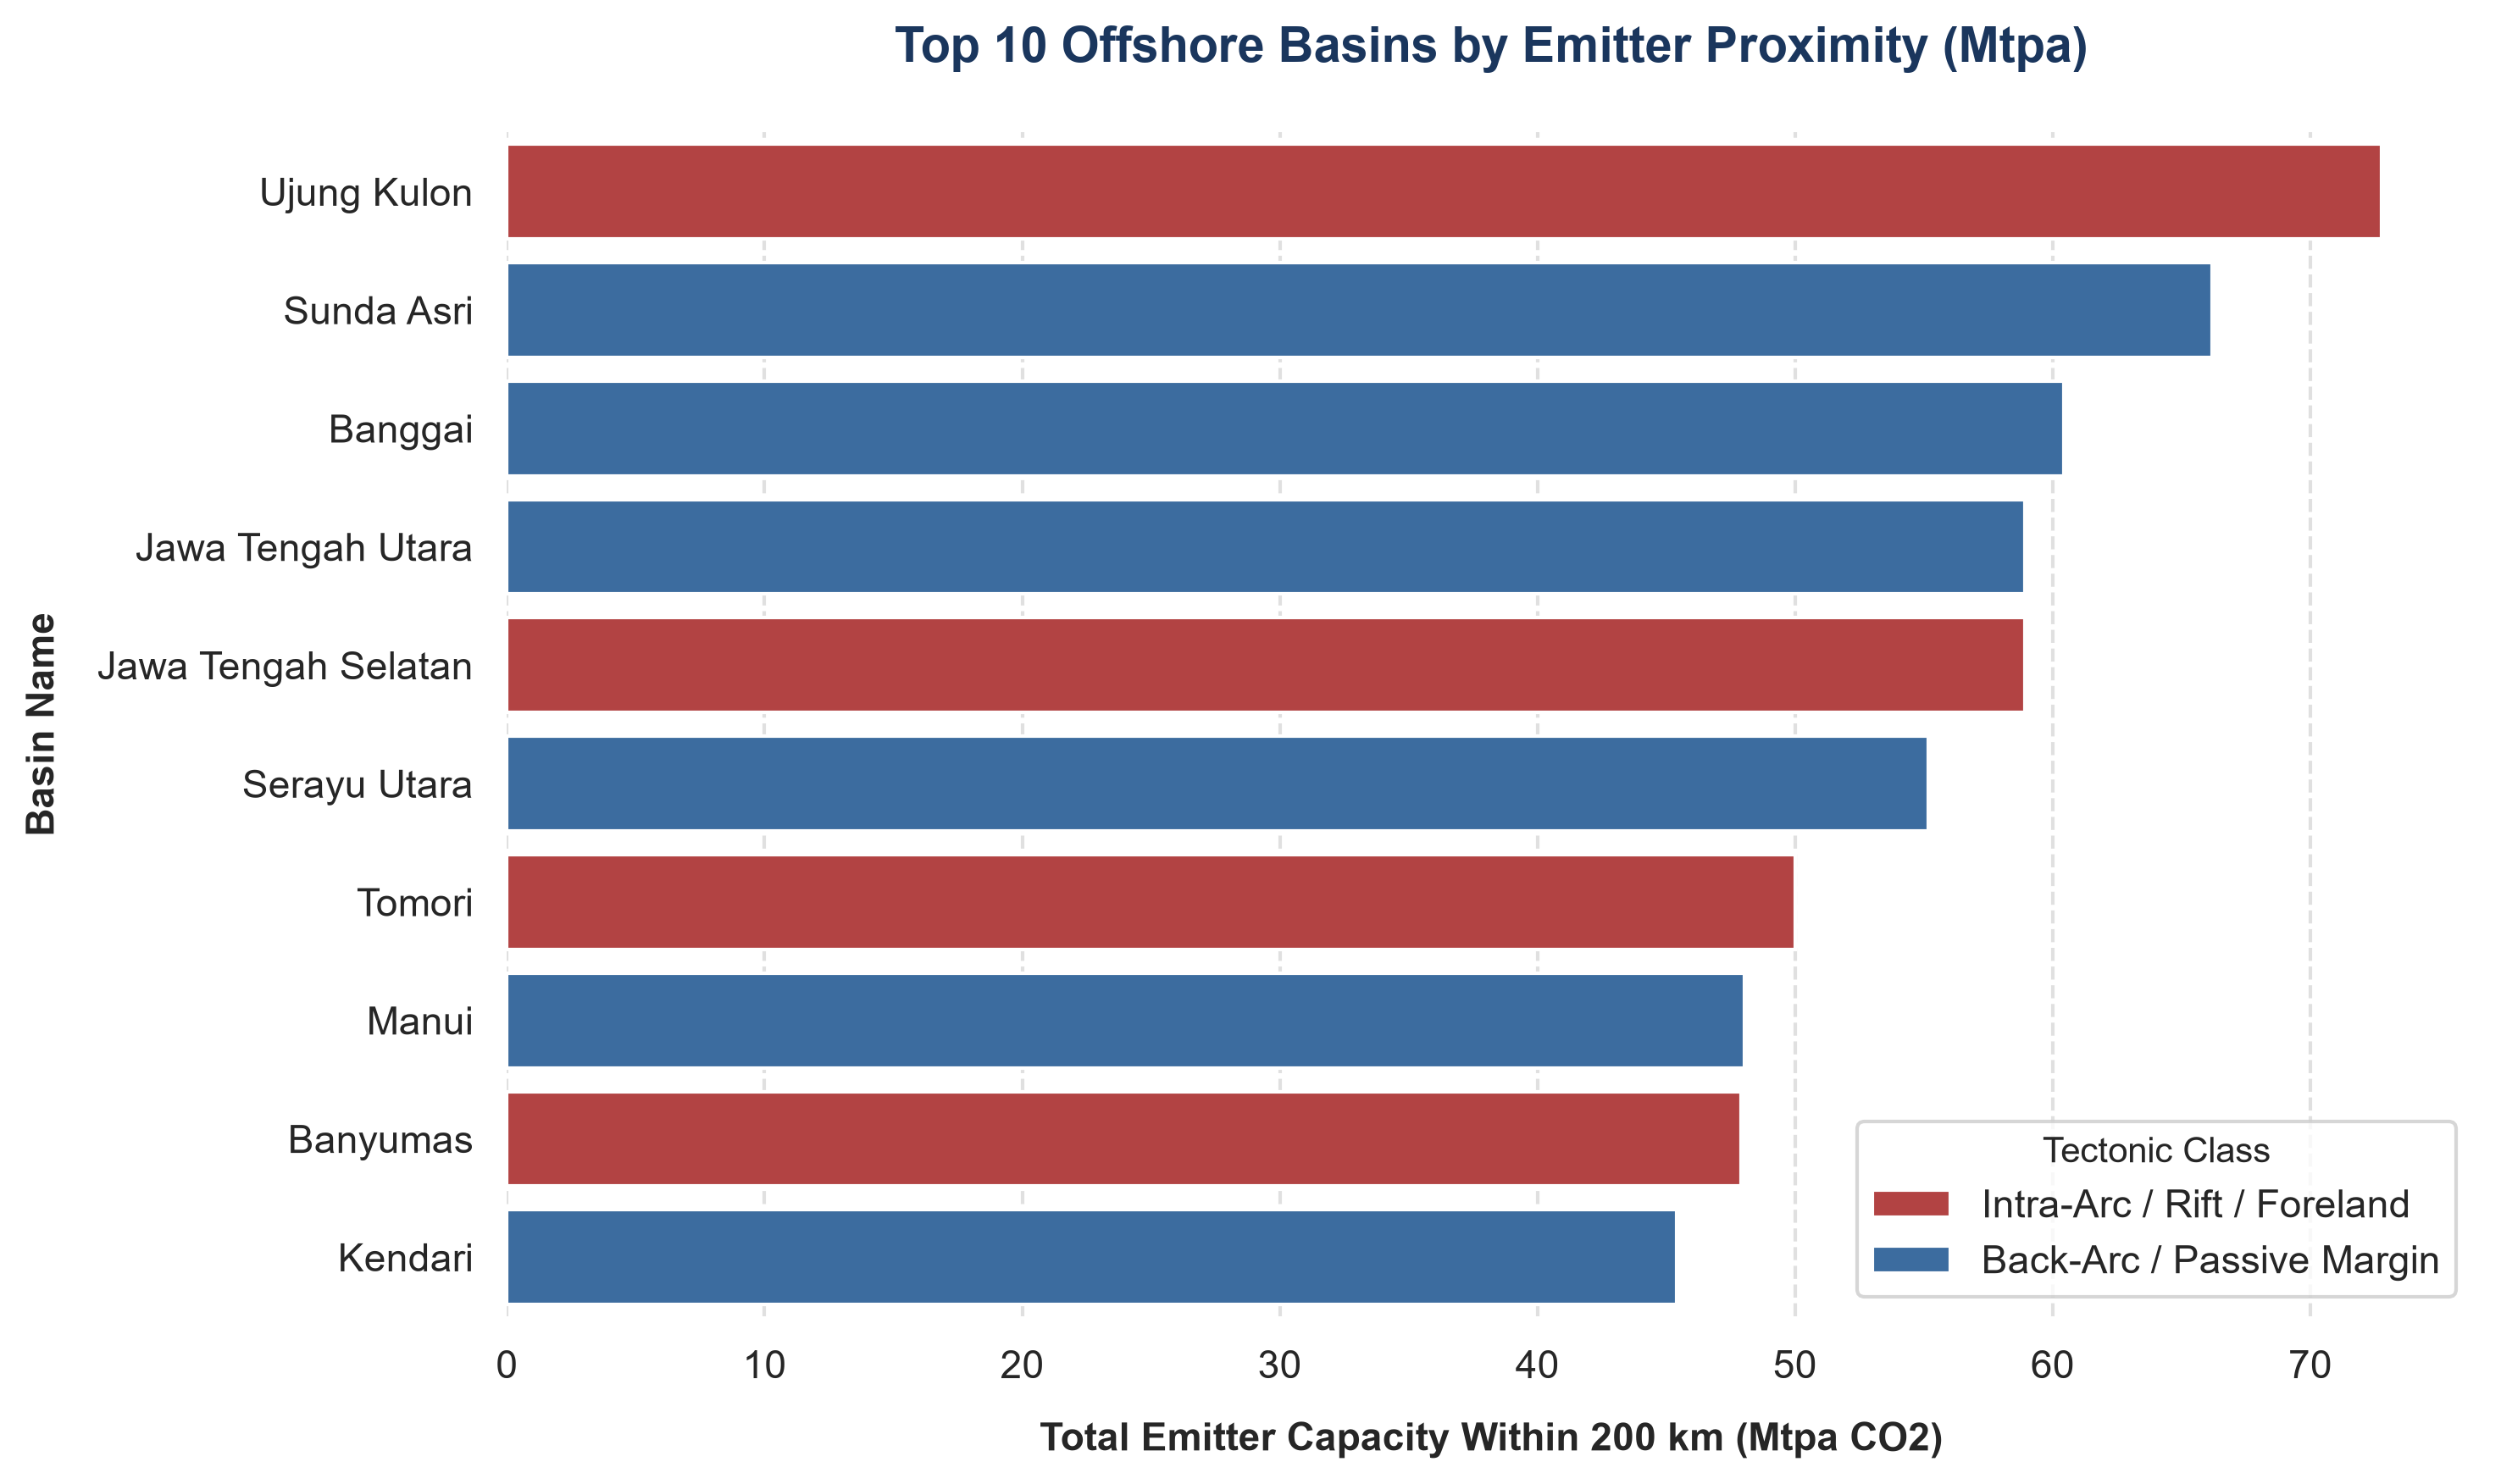

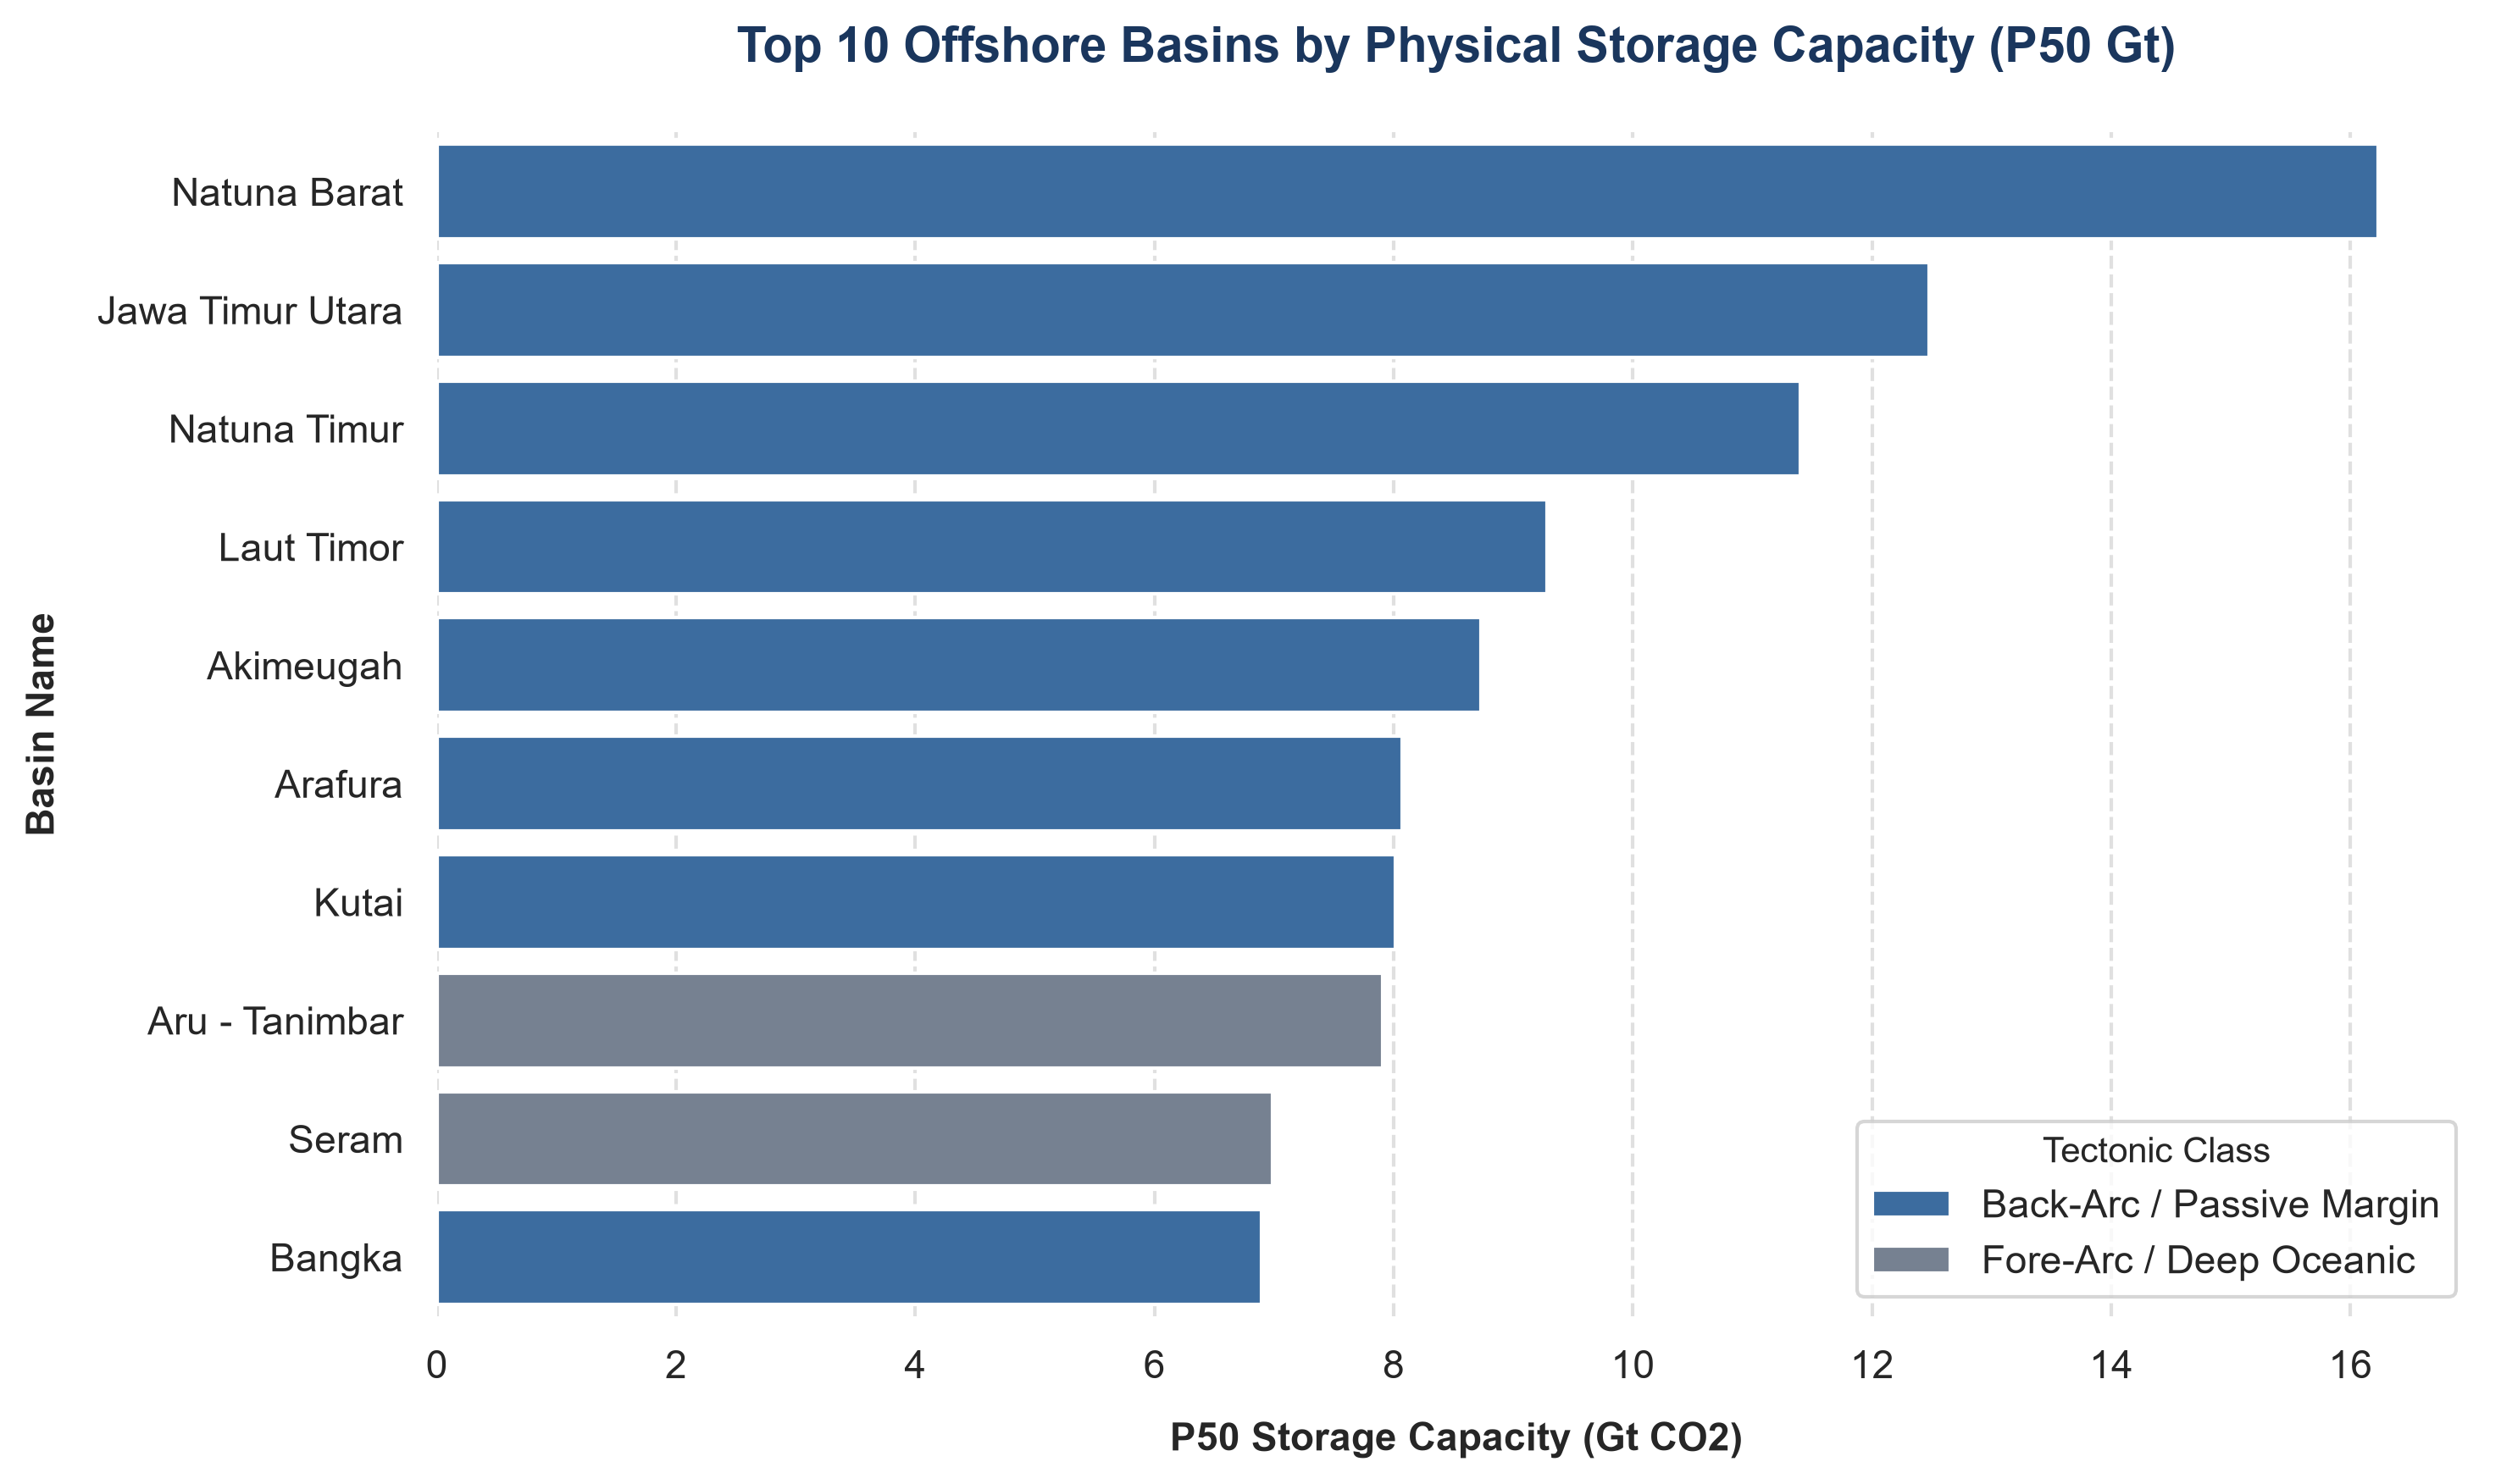

In [10]:

sns.set_theme(style="whitegrid")
figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Unified color mapping for Tectonic Classes
palette_colors = {
    "Back-Arc / Passive Margin": "#2B6CB0",        # Safe / High Priority (Blue)
    "Intra-Arc / Rift / Foreland": "#C53030",      # Caution / Medium (Red)
    "Fore-Arc / Deep Oceanic": "#718096",          # High Risk (Gray)
    "Unclassified / Intermediate": "#ED8936"       # Unknown (Orange)
}

# ---------------------------------------------------------
# 1. HORIZONTAL BAR CHART: EMITTER PROXIMITY (300 DPI)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.barplot(
    x="total_capacity_within_radius_mtpa",
    y="basin",
    hue="tectonic_class",
    data=emitter_sorted.reset_index().head(10),
    palette=palette_colors,
    dodge=False,
    ax=ax
)

ax.set_title("Top 10 Offshore Basins by Emitter Proximity (Mtpa)", fontsize=14, fontweight='bold', pad=20, color='#1A365D')
ax.set_xlabel("Total Emitter Capacity Within 200 km (Mtpa CO2)", fontsize=11, fontweight='semibold', labelpad=10)
ax.set_ylabel("Basin Name", fontsize=11, fontweight='semibold', labelpad=10)

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False) 
ax.legend(title="Tectonic Class", title_fontsize='10', loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig(figures_dir / "top_basins_proximity_bar.png", bbox_inches='tight', dpi=300)
plt.show()


# ---------------------------------------------------------
# 2. HORIZONTAL BAR CHART: STORAGE CAPACITY (300 DPI)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=300)

sns.barplot(
    x="P50_Gt",
    y="basin",
    hue="tectonic_class",
    data=storage_sorted.reset_index().head(10),
    palette=palette_colors,
    dodge=False,
    ax=ax2
)

ax2.set_title("Top 10 Offshore Basins by Physical Storage Capacity (P50 Gt)", fontsize=14, fontweight='bold', pad=20, color='#1A365D')
ax2.set_xlabel("P50 Storage Capacity (Gt CO2)", fontsize=11, fontweight='semibold', labelpad=10)
ax2.set_ylabel("Basin Name", fontsize=11, fontweight='semibold', labelpad=10)

sns.despine(left=True, bottom=True)
ax2.xaxis.grid(True, linestyle='--', alpha=0.6)
ax2.yaxis.grid(False) 
ax2.legend(title="Tectonic Class", title_fontsize='10', loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig(figures_dir / "top_basins_storage_bar.png", bbox_inches='tight', dpi=300)
plt.show()


In [11]:

import folium
from folium.plugins import HeatMap

m = folium.Map(location=[-2.5, 113], zoom_start=5, tiles="cartodbpositron")

# Heatmap Layer (Weighted by Capacity)
heat_data = [
    [row["lat"], row["lon"], row.get("capacity_mtpa_co2_est", 1.0) if pd.notna(row.get("capacity_mtpa_co2_est", 1.0)) else 1.0]
    for _, row in emitters.iterrows()
]
HeatMap(heat_data, name="Emitter density (weighted by capacity)", radius=22, blur=18, max_zoom=6).add_to(
    folium.FeatureGroup(name="Emitter heatmap").add_to(m)
)

# Catchment Circles (200km radius around SRL 2 basins)
radius_layer = folium.FeatureGroup(name=f"{ts['search_radius_km']} km catchment radius")
for _, row in basins_scored.iterrows():
    folium.Circle(
        location=[row["lat"], row["lon"]], radius=ts["search_radius_km"] * 1000,
        color="#f39c12", weight=1, fill=True, fill_opacity=0.04, dash_array="4",
    ).add_to(radius_layer)
radius_layer.add_to(m)

# Basin Markers (Color-coded by Top 3 Elite Status)
basin_layer = folium.FeatureGroup(name="SRL 2 Offshore Basins")
for basin_name, row in ranking_df.iterrows():
    is_elite = basin_name in robust_picks

    if is_elite:
        color = "#2ecc71"  # Top 3 Winner -> Green
    elif row["tectonic_score"] < 2:
        color = "#e74c3c"  # Fore-Arc -> Red
    else:
        color = "#e67e22"  # Filtered out (Prospect / Rift / etc) -> Orange

    radius_px = 10 + 12 * row["norm_volume_global"]
    
    score_text = f"Cost-Effective Score: {row['cost_effective_score']:.3f}<br>" if pd.notna(row['cost_effective_score']) else "Filtered out of Top 3 ranking.<br>"
    
    popup_html = (
        f"<b>{basin_name}</b><br>"
        f"Status: {row['status']}<br>"
        f"Tectonic: {row['tectonic_class']}<br>"
        f"Storage: {row['P50_Gt']:.2f} Gt<br>"
        f"CO2 Reach: {row['total_capacity_within_radius_mtpa']:.2f} Mtpa<br>"
        f"{score_text}"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=radius_px, color=color, fill=True, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=280),
    ).add_to(basin_layer)
    folium.map.Marker(
        [row["lat"], row["lon"]],
        icon=folium.DivIcon(html=f'<div style="font-size:10px; font-weight:bold; color:#2c3e50; '
                                  f'text-shadow:1px 1px 2px white;">{basin_name}</div>'),
    ).add_to(basin_layer)
basin_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save(str(figures_dir / "tier1_indonesia_basins_map.html"))
print(f"Interactive map saved.")
m


Interactive map saved.


### 5a. Computational cross-check summary

In [12]:

print(f"{'='*75}\nTIER 1 COMPUTATIONAL CROSS-CHECK\n{'='*75}")
if robust_picks:
    print(f"Top 3 Cost-Effective Candidates (Post-Hard Filter):")
    for idx, pick in enumerate(robust_picks, 1):
        print(f"  {idx}. {pick} (Score: {df_scoring.loc[pick, 'cost_effective_score']:.3f})")
else:
    print(f"No single basin dominates (Hard filters may be too strict).")
print(f"{'='*75}")


TIER 1 COMPUTATIONAL CROSS-CHECK
Top 3 Cost-Effective Candidates (Post-Hard Filter):
  1. Sunda Asri (Score: 0.678)
  2. Banggai (Score: 0.671)
  3. Jawa Timur Utara (Score: 0.587)


### 5b. How this relates to the Tier 2 basin choice

**This notebook does not independently select the Tier 2 basin.** Per `docs/methodology.md` §3,
the basin taken forward is justified on three qualitative grounds:
government policy priority, structural analogy to baseline literature, and the data-driven recommendation computed here. 
The ranking above acts as a **sanity-check**, ensuring the chosen basin isn't an outlier 
on the dimensions this notebook measures (volumetric capacity, emitter proximity, and geological stability).

In [14]:

tier2_basin_name = cfg.get("tier2", {}).get("basin_name", "Sunda Asri")

if tier2_basin_name in ranking_df.index:
    row = ranking_df.loc[tier2_basin_name]
    print(f"Tier 2 basin '{tier2_basin_name}' cross-check against this notebook's SRL 2 ranking:")
    print(f"  Tectonic setup                : {row['tectonic_class']}")
    print(f"  Status                        : {row['status']}")
    print(f"  Storage (P50 Gt)              : {row['P50_Gt']:.2f}")
    print(f"  Proximity (Mtpa in 200km)     : {row['total_capacity_within_radius_mtpa']:.2f}")
    
    if pd.notna(row['cost_effective_score']):
        print(f"  Cost-Effective score          : {row['cost_effective_score']:.3f}")
        print(f"  In Top 3 Recommended list?      {tier2_basin_name in robust_picks}")
    else:
        print(f"  Cost-Effective score          : Filtered (Did not pass hard geology/status gate)")
else:
    print(f"Tier 2 basin '{tier2_basin_name}' is not present in this run's offshore SRL 2 ranking.")


Tier 2 basin 'Sunda Asri' cross-check against this notebook's SRL 2 ranking:
  Tectonic setup                : Back-Arc / Passive Margin
  Status                        : Producing basin
  Storage (P50 Gt)              : 3.50
  Proximity (Mtpa in 200km)     : 66.19
  Cost-Effective score          : 0.678
  In Top 3 Recommended list?      True


## 6. Summary & next steps